## Predicting and auditing online purchase intention from completed web sessions

### A post-session conversion-driver audit

A post-session conversion-driver analysis using the UCI Online Shoppers dataset. The objective is a post-session audit: given a completed session, predict whether it converted and identify which behaviours drive conversion, so an analyst can review and learn from real sessions. The dataset carries no marketing channel, campaign or customer-identity fields, so no attribution claim is made.


[1] C. Sakar and Y. Kastro, “Online Shoppers Purchasing Intention Dataset,” UCI Machine Learning Repository, 2018. [Online]. Available: https://doi.org/10.24432/C5F88Q
[2] scikit-learn developers, "LogisticRegression," scikit-learn, 2026. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

# Section 1: The Data

## Imports and settings

A fixed `RANDOM_STATE` keeps the split, tuning and resampling reproducible.

In [84]:
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from packaging import version
REQ_SKLEARN_VERSION = "1.8"
if version.parse(sklearn.__version__) < version.parse(REQ_SKLEARN_VERSION):
    raise RuntimeError(
        f"This notebook needs scikit-learn >= {REQ_SKLEARN_VERSION} "
        f"for the `LogisticRegression` `l1_ratio` API. "
        f"Current version: {sklearn.__version__}"
    )
print("scikit-learn", sklearn.__version__)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import mutual_info_classif, SelectKBest
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    make_scorer, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
CV_STRATEGY = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scikit-learn 1.8.0


The output folders are defined once so fitted models and cached result tables can be saved consistently. This avoids rerunning expensive tuning cells during editing, while keeping the notebook paths clear and reproducible.

In [83]:
OUTPUT_DIR = Path("../outputs")
MODEL_DIR = OUTPUT_DIR / "models"
CACHE_DIR = OUTPUT_DIR / "cache"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

## Shared preprocessing, pipeline and tuning helpers

To keep the model experiments consistent and fair, small helper functions are defined once and reused throughout. `build_preprocessor` standardises the numeric columns and one-hot encodes the categorical ones, while `build_model_pipeline` wraps each model with a cloned preprocessor so every pipeline stays independent.

`build_random_search` then applies the same tuning design to each selected model: `F1` scoring, five-fold cross-validation, the same `random_state`, and parallel processing. 

In [2]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
        ],
        sparse_threshold=0
    )

def build_model_pipeline(model, preprocessor):
    # clone keeps each pipeline independent
    return Pipeline(steps=[
        ("preprocessor", clone(preprocessor)),
        ("model", model)
    ])

def build_random_search(pipeline, param_grid, n_iter):
    return RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=n_iter,
        scoring="f1",
        cv=CV_STRATEGY,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def clean_feature_names(names):
    return [name.replace("num__", "").replace("cat__", "") for name in names]

## Initial data examination

In [3]:
df = pd.read_csv("../data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


Each row represents a completed web session, with `Revenue` used as the binary purchase target. 

The input features combine browsing activity, such as page counts and durations, with engagement signals such as `BounceRates`, `ExitRates` and `PageValues`. 

The dataset also includes session context, including `Month`, `VisitorType` and `Weekend`, together with coded technical fields such as operating system, browser, region and traffic type.

## Initial inspection

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

The dataset has 12,330 rows, 18 columns, no nulls reported.

The data contains a mixture of types: integers, floats, strings and Boolean values. Categorical and Boolean fields need encoding before modelling.

## Data quality: duplicates

Exact duplicates are inspected before any modelling decisions are made, because repeated rows can distort both class balance and model evaluation.

In [5]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(125)

In [6]:
duplicate_rows = df[df.duplicated(keep=False)].copy()

duplicate_rows_summary = pd.DataFrame({
    "duplicate_rows_including_originals": [len(duplicate_rows)],
    "duplicate_groups": [duplicate_rows.groupby(list(df.columns)).ngroups],
    "max_repeated_group_size": [
        duplicate_rows.groupby(list(df.columns)).size().max()
    ],
    "purchase_duplicates": [duplicate_rows["Revenue"].sum()],
    "non_purchase_duplicates": [(duplicate_rows["Revenue"] == False).sum()],
    "max_product_duration_in_duplicates": [
        duplicate_rows["ProductRelated_Duration"].max()
    ]
})

duplicate_rows_summary

,duplicate_rows_including_originals,duplicate_groups,max_repeated_group_size,purchase_duplicates,non_purchase_duplicates,max_product_duration_in_duplicates
0,201,76,14,0,201,0.0


The duplicate check found 201 rows involved in duplication, grouped into 76 repeated session patterns. After keeping one copy of each pattern, this means 125 rows would be removed. The largest repeated pattern appears 14 times.

All duplicated patterns are non-purchase sessions, and their maximum `ProductRelated_Duration` is 0. This suggests repeated empty or very short visits rather than additional behavioural evidence. 

*Design choice: Removing the duplicates will help to avoid strengthening the majority class with repeated non-purchase records, while keeping the modelling dataset focused on distinct session behaviour.*

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(12205, 18)

12,205 sessions remain. No purchase sessions were lost, so the imbalance is now slightly less extreme but still large, which shapes the validation strategy and metric choice later.

## Target imbalance

In [8]:
revenue_summary = pd.DataFrame({
    "count": df["Revenue"].value_counts(),
    "percentage": df["Revenue"].value_counts(normalize=True) * 100
})

revenue_summary

,count,percentage
Revenue,,
False,10297,84.367063
True,1908,15.632937


Only 15.6% of sessions convert to `Revenue` (1,908 of 12,205). This class imbalance means accuracy could be misleading: a model that predicts “no purchase” for every session would still achieve about 84% accuracy, but would identify no buyers.

For this reason, accuracy is treated as a secondary measure. Model selection focuses on purchase-class precision, recall, F1-score and the confusion matrix, because these show how well the model identifies the smaller but more important purchase class.

In [9]:
scale_check = df.describe().loc[["min", "50%", "max", "std"]].T

scale_check = scale_check.rename(columns={"50%": "median"})
scale_check["range"] = scale_check["max"] - scale_check["min"]

scale_check.sort_values("range", ascending=False)

,min,median,max,std,range
ProductRelated_Duration,0.0,608.942857,63973.522230,1919.601400,63973.522230
Administrative_Duration,0.0,9.000000,3398.750000,177.491845,3398.750000
Informational_Duration,0.0,0.000000,2549.375000,141.424807,2549.375000
ProductRelated,0.0,18.000000,705.000000,44.593649,705.000000
PageValues,0.0,0.000000,361.763742,18.653671,361.763742
Administrative,0.0,1.000000,27.000000,3.330436,27.000000
Informational,0.0,0.000000,24.000000,1.275617,24.000000
TrafficType,1.0,2.000000,20.000000,4.016654,19.000000
Browser,1.0,2.000000,13.000000,1.710114,12.000000
Region,1.0,3.000000,9.000000,2.402340,8.000000


The scale check shows why standardisation is needed: `ProductRelated_Duration` reaches almost 64,000 seconds, while `BounceRates` and `ExitRates` stay between 0 and 0.2. Without scaling, models such as KNN, SVM and Logistic Regression could be pulled towards the largest-value features, motivating standardisation inside the pipeline rather than edits to the raw data.

In [10]:
df.sort_values("ProductRelated_Duration", ascending=False).head(10)[
    ["ProductRelated", "ProductRelated_Duration", "PageValues", "BounceRates", "ExitRates", "Revenue"]
]

,ProductRelated,ProductRelated_Duration,PageValues,BounceRates,ExitRates,Revenue
7983,449,63973.52223,0.000000,0.000764,0.027701,False
5074,705,43171.23338,0.763829,0.004851,0.015431,False
9149,343,29970.46597,0.000000,0.005316,0.028971,False
8695,517,27009.85943,8.403164,0.004385,0.014594,True
8220,584,24844.15620,4.511100,0.002099,0.009347,False
7574,414,23888.81000,1.033757,0.009900,0.027062,False
6599,686,23342.08205,0.150650,0.009853,0.022771,False
6080,486,23050.10414,0.000000,0.000324,0.011249,False
5831,439,21857.04648,11.439233,0.003589,0.012498,False
8883,501,21672.24425,9.131387,0.003965,0.014292,True


The longest `ProductRelated_Duration` values (~63,974 seconds, ~17.8 hours) are not duplicates. They carry distinct `ProductRelated`, `PageValues` and `rate` values. These seem to be long or idle-tab sessions, so they are retained rather than treated as errors.

In [11]:
categorical_cols = ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]

categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_cols].nunique(),
    "most_common_value": df[categorical_cols].mode().iloc[0],
    "most_common_count": [df[col].value_counts().iloc[0] for col in categorical_cols],
    "most_common_percentage": [
        df[col].value_counts(normalize=True).iloc[0] * 100
        for col in categorical_cols
    ]
})

categorical_summary["most_common_percentage"] = (
    categorical_summary["most_common_percentage"].round(2)
)

categorical_summary

,unique_values,most_common_value,most_common_count,most_common_percentage
Month,10,May,3329,27.28
VisitorType,3,Returning_Visitor,10431,85.46
Weekend,2,False,9346,76.58
OperatingSystems,8,2,6541,53.59
Browser,13,2,7883,64.59
Region,9,1,4714,38.62
TrafficType,20,2,3911,32.04


The categorical and coded fields are unevenly distributed. `Returning_Visitor` accounts for 85.5% of sessions, while `Browser` value 2 and `OperatingSystems` value 2 account for 64.6% and 53.6%. Their integers are labels, not quantities, so they are one-hot encoded. The skew is also worth keeping in mind when interpreting one-hot feature scores later, because rare categories can carry limited evidence.

## Behavioural differences between buyers and non-buyers

In [12]:
df.groupby("Revenue")[["PageValues", "BounceRates", "ExitRates", "ProductRelated", "ProductRelated_Duration"]].mean()

,PageValues,BounceRates,ExitRates,ProductRelated,ProductRelated_Duration
Revenue,,,,,
False,1.999985,0.023197,0.045526,29.050403,1082.976881
True,27.264518,0.005117,0.019555,48.210168,1876.209615


The grouped averages show a clear behavioural difference between purchase and non-purchase sessions. Purchase sessions have much higher average `PageValues` at 27.3 compared with 2.0, along with more product page visits, longer product browsing time and lower bounce and exit rates.

This suggests that browsing depth and page value may be useful predictors. `PageValues` does most of the separating, a point examined critically below before it is trusted.

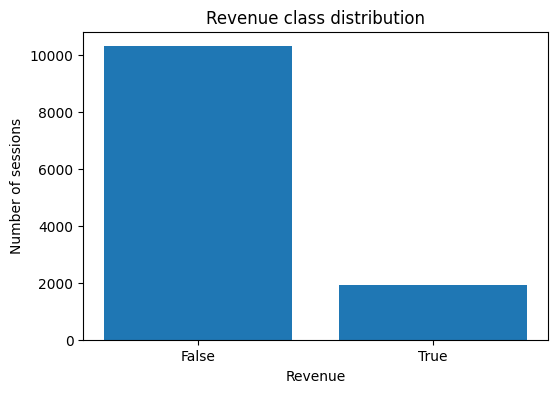

In [13]:
revenue_counts = df["Revenue"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(revenue_counts.index.astype(str), revenue_counts.values)
plt.title("Revenue class distribution")
plt.xlabel("Revenue")
plt.ylabel("Number of sessions")
plt.show()

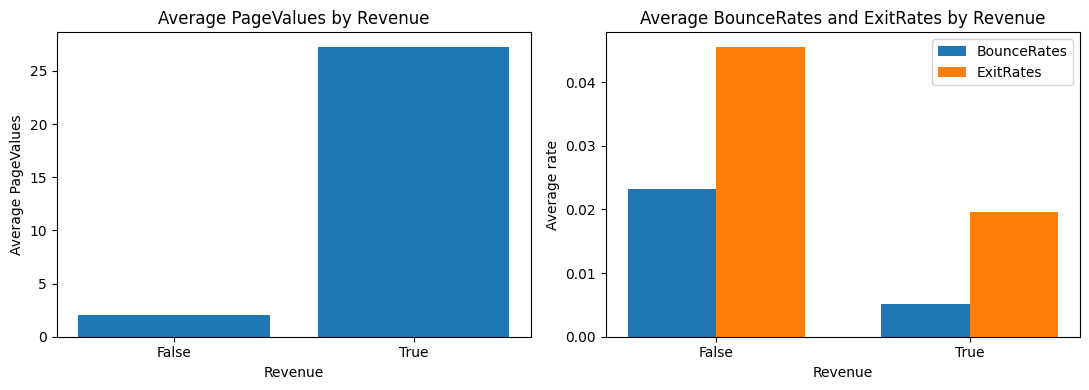

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

pagevalues_mean = df.groupby("Revenue")["PageValues"].mean()
axes[0].bar(pagevalues_mean.index.astype(str), pagevalues_mean.values)
axes[0].set_title("Average PageValues by Revenue")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Average PageValues")

rate_means = df.groupby("Revenue")[["BounceRates", "ExitRates"]].mean()
x = np.arange(len(rate_means.index))
width = 0.35
axes[1].bar(x - width/2, rate_means["BounceRates"], width, label="BounceRates")
axes[1].bar(x + width/2, rate_means["ExitRates"], width, label="ExitRates")
axes[1].set_title("Average BounceRates and ExitRates by Revenue")
axes[1].set_xlabel("Revenue")
axes[1].set_ylabel("Average rate")
axes[1].set_xticks(x)
axes[1].set_xticklabels(rate_means.index.astype(str))
axes[1].legend()

plt.tight_layout()
plt.show()

The charts make the gap clear. Buyers have significantly higher `PageValues` and markedly lower bounce/exit rates. Visitors who stay and move through product pages convert more often, so engagement and exit behaviour are promising signals, therefore these features are carried forward into mutual information and permutation importance feature checks.

### A design note on `PageValues`

`PageValues` is a Google Analytics metric that represents the average value of pages a visitor saw before completing an e-commerce transaction [1]. It is retained for this project because the audit is post-session. It would be excluded only in a live-intervention model.

## Preprocessing plan

The preprocessing is kept inside the modelling pipeline so each transform is fitted only on the training data used in that fold. This is the main leakage-control step.

Continuous numeric features are standardised because the duration variables are much larger than the rate features, which matters for `KNN`, `SVM` and `Logistic Regression`. The same preprocessing structure is used across models for consistency, even though tree-based models are not sensitive to feature scale. Categorical fields are one-hot encoded because values such as `Month`, `VisitorType`, `Browser` and `TrafficType` are labels rather than numeric measurements.

# Section 2: Constructing and Selecting Features

## Feature and target split

In [15]:
# Separate the input features from the target variable
X_original = df.drop(columns=["Revenue"])
y = df["Revenue"]

print("Feature data shape:", X_original.shape)
print("Target data shape:", y.shape)

Feature data shape: (12205, 17)
Target data shape: (12205,)


In [16]:
categorical_features = [
    "Month",
    "VisitorType",
    "Weekend",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

numerical_features_original = [
    col for col in X_original.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features_original)

Categorical features:
['Month', 'VisitorType', 'Weekend', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']

Numerical features:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


The columns are separated into categorical and numerical features before preprocessing. The UCI description groups the dataset into 10 numerical attributes and 8 categorical attributes [1]. `Weekend` is included with the categorical features because it describes the session type rather than a measured quantity. `OperatingSystems`, `Browser`, `Region` and `TrafficType` are also treated as categorical because their values are coded labels, not numbers with a meaningful order. The remaining ten fields are treated as numerical browsing-behaviour features, including page counts, page durations, Google Analytics rates, `PageValues` and `SpecialDay`.

In [17]:
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_original.shape)
print("Test features:", X_test_original.shape)
print("Training target:", y_train_original.shape)
print("Test target:", y_test_original.shape)

Training features: (9764, 17)
Test features: (2441, 17)
Training target: (9764,)
Test target: (2441,)


An 80/20 train-test split is used with `stratify=y`, keeping the 15.6% purchase rate consistent across both sets. This gives the models enough data to learn from, while keeping a held-out test set that reflects the original class balance. The test set is kept back until final evaluation.

In [18]:
split_balance = pd.DataFrame({
    "train_percentage": y_train_original.value_counts(normalize=True) * 100,
    "test_percentage": y_test_original.value_counts(normalize=True) * 100
})

split_balance

,train_percentage,test_percentage
Revenue,,
False,84.371159,84.350676
True,15.628841,15.649324


In [19]:
preprocessor_original = build_preprocessor(numerical_features_original, categorical_features)

print(preprocessor_original)

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num', StandardScaler(),
                                 ['Administrative', 'Administrative_Duration',
                                  'Informational', 'Informational_Duration',
                                  'ProductRelated', 'ProductRelated_Duration',
                                  'BounceRates', 'ExitRates', 'PageValues',
                                  'SpecialDay']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Month', 'VisitorType', 'Weekend',
                                  'OperatingSystems', 'Browser', 'Region',
                                  'TrafficType'])])


The original-feature preprocessor standardises the ten numerical columns and one-hot encodes the seven categorical columns. This gives every classifier the same all-numeric input while keeping the preprocessing logic in one shared pipeline.

## Filter-based feature selection: mutual information

Mutual information is computed on the training data only, so feature analysis never sees the test set. The aim is to map the strongest individual signals before modelling.

In [20]:
mi_preprocessor = clone(preprocessor_original)

X_train_processed = mi_preprocessor.fit_transform(X_train_original)
processed_feature_names = mi_preprocessor.get_feature_names_out()

mi_scores = mutual_info_classif(
    X_train_processed,
    y_train_original,
    random_state=RANDOM_STATE
)

mi_scores_df = (
    pd.DataFrame({"feature": processed_feature_names, "mutual_information": mi_scores})
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

mi_scores_display_df = mi_scores_df.copy()
mi_scores_display_df["feature"] = clean_feature_names(mi_scores_display_df["feature"])
mi_scores_display_df.head(15)

,feature,mutual_information
0,PageValues,0.163820
1,ExitRates,0.037809
2,ProductRelated_Duration,0.032262
3,BounceRates,0.020914
4,ProductRelated,0.019765
5,Administrative,0.017184
6,Month_Nov,0.013419
7,SpecialDay,0.009886
8,TrafficType_15,0.009080
9,Administrative_Duration,0.008649


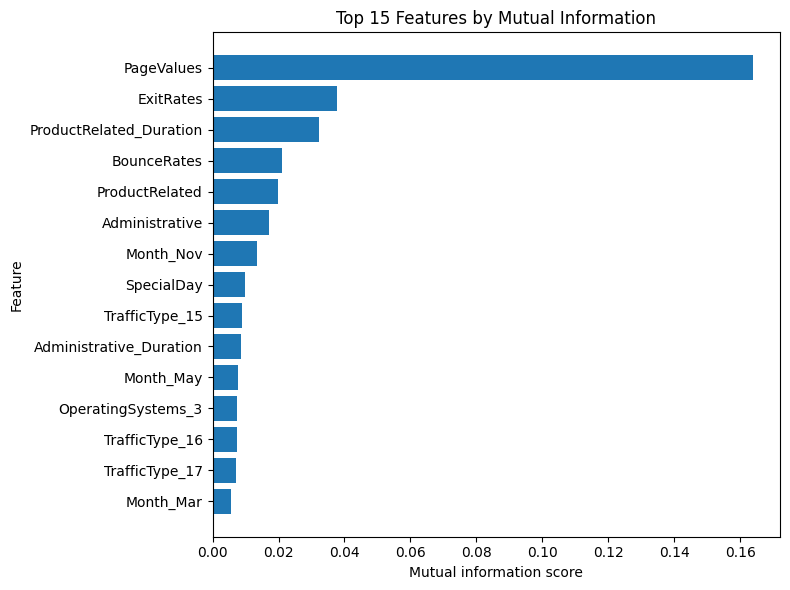

In [21]:
top_mi_features = mi_scores_display_df.head(15).sort_values("mutual_information")

plt.figure(figsize=(8, 6))
plt.barh(top_mi_features["feature"], top_mi_features["mutual_information"])
plt.xlabel("Mutual information score")
plt.ylabel("Feature")
plt.title("Top 15 Features by Mutual Information")
plt.tight_layout()
plt.show()

`PageValues` leads at 0.164, roughly four times the next feature. The rest of the top features are session-quality signals: `ExitRates` at 0.038, `ProductRelated_Duration` at 0.032, `BounceRates` at 0.021 and `ProductRelated` at 0.020.

One caveat is that mutual information is scored per one-hot column, so a multi-level field like `Month` is split across dummy variables and its overall signal may be understated here. This is checked later with model-based importance.

### SelectKBest and the feature-selection decision

`SelectKBest` applies the mutual information ranking as a formal filter-based feature selection step. It confirms which features would be retained under a top-k selection rule.

The final models still use the full feature set because lower-ranked variables may add value in combination with stronger predictors. Therefore, this step is used for feature analysis and interpretation rather than permanent feature removal.

In [22]:
TOP_K_FEATURES = 5

def reproducible_mutual_info(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE
    )

selected_feature_selector = SelectKBest(
    score_func=reproducible_mutual_info,
    k=TOP_K_FEATURES
)

selected_feature_selector.fit(X_train_processed, y_train_original)

selected_features_df = (
    pd.DataFrame({
        "selected_feature": processed_feature_names[selected_feature_selector.get_support()],
        "mutual_information": selected_feature_selector.scores_[selected_feature_selector.get_support()]
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

selected_features_df

,selected_feature,mutual_information
0,num__PageValues,0.163820
1,num__ExitRates,0.037809
2,num__ProductRelated_Duration,0.032262
3,num__BounceRates,0.020914
4,num__ProductRelated,0.019765


The selected features are all linked to completed-session behaviour. `PageValues` is the dominant feature, while `ExitRates`, `BounceRates`, `ProductRelated` and `ProductRelated_Duration` provide weaker but still relevant browsing-behaviour signals.

SelectKBest turns the mutual-information ranking into a formal top-k filter. With k = 5 it keeps PageValues, ExitRates, ProductRelated_Duration, BounceRates and ProductRelated, all of which are completed-session behaviour.

No features are dropped here. Mutual information scores each feature on its own, so lower-ranked features may still help when combined with others. Contextual fields such as `Month`, `VisitorType`, `TrafficType` and `Weekend` are also kept for possible seasonal or visitor pattern effects.

Whether a reduced set actually preserves performance is a model-level question, so it is tested in Section 3 once candidate models exist. At this point, the main takeaway is that the strongest individual signals are session activity features, which is where the later feature-engineering cycle focuses.

# Section 3: Building ML Algorithms


This is a supervised binary classification task because each session has a known `Revenue` label.

Eight classifiers span the main families so the comparison is not tied to one assumption: linear (`Logistic Regression`), kernel (`Support Vector Machine`), instance-based (`K-Nearest Neighbours`), single-tree (`Decision Tree`), bagged and boosted ensembles (`Random Forest`, `Gradient Boosting`, `Hist Gradient Boosting`) and a neural network (`MLPClassifier`).

## 3.1 Baseline comparison: controlled algorithm comparison

The baseline models are run without class weighting so the first comparison uses the same basic setup for every classifier. This keeps the screen focused on the algorithms themselves, rather than mixing algorithm performance with different imbalance-handling options. Class imbalance is still accounted for through the evaluation metrics, then handled more directly during tuning.

A shared evaluation helper reports the confusion matrix and purchase-class precision, recall and F1-score for every model.

In [23]:
def evaluate_model(model_name, model, X_test, y_test):
    
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=True, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=True, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=True, zero_division=0)
    }
    
    print("\n" + model_name)
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return results, y_pred, cm

In [24]:
# Baseline models: no class weighting, so the screen is like-for-like across families.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "K-Nearest Neighbours": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLPClassifier": MLPClassifier(max_iter=500, random_state=RANDOM_STATE)
}

In [25]:
baseline_results = []
trained_pipelines = {}
baseline_predictions = {}
baseline_confusion_matrices = {}

for model_name, model in models.items():
    pipeline = build_model_pipeline(clone(model), preprocessor_original)

    pipeline.fit(X_train_original, y_train_original)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_original,
        y_test_original
    )

    baseline_results.append(results)
    trained_pipelines[model_name] = pipeline
    baseline_predictions[model_name] = y_pred
    baseline_confusion_matrices[model_name] = cm



Logistic Regression
Confusion matrix:
[[2007   52]
 [ 224  158]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.97      0.94      2059
        True       0.75      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.73      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1875  184]
 [ 166  216]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.91      2059
        True       0.54      0.57      0.55       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.73      2441
weighted avg       0.86      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1994   65]
 [ 170  212]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [78]:
baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590
2,Random Forest,0.903728,0.765343,0.554974,0.643399
4,Support Vector Machine,0.895535,0.736059,0.518325,0.608295
7,MLPClassifier,0.878329,0.617729,0.583770,0.600269
1,Decision Tree,0.856616,0.540000,0.565445,0.552430
0,Logistic Regression,0.886932,0.752381,0.413613,0.533784
3,K-Nearest Neighbours,0.873413,0.662222,0.390052,0.490939


In [79]:
baseline_results_df.to_csv(CACHE_DIR / "baseline_results_df.csv", index=False)

On the unweighted baseline screen, the boosting models lead on purchase-class F1, the score used here to balance how many buyers are found with how many purchase predictions are correct. `Hist Gradient Boosting` scores `0.674` and `Gradient Boosting` scores `0.668`.

The precision and recall split shows why tuning is needed. `Random Forest` has strong precision but lower recall at `P 0.765 / R 0.555`, while `Logistic Regression` at `P 0.752 / R 0.414` and `SVM` at `P 0.736 / R 0.518` are also cautious. They make relatively accurate purchase predictions when they do predict purchase, but still miss many actual buyers. This is the gap that class weighting and model tuning target.

`Gradient Boosting`, `Hist Gradient Boosting`, `Random Forest`, `SVM`, `Logistic Regression` and `MLPClassifier` are carried forward for tuning. `MLPClassifier` is included as a different model family, with tuning used to address the convergence warning from the baseline run.

## 3.2 Exploratory model-based importance

Gradient Boosting gives a quick model-side view of feature importance before tuning. This is exploratory, because built-in importance is model-specific and one-hot encoded fields are split across separate dummy columns.

In [27]:
gb_pipeline = trained_pipelines["Gradient Boosting"]

gb_model = gb_pipeline.named_steps["model"]
gb_preprocessor = gb_pipeline.named_steps["preprocessor"]
feature_names = clean_feature_names(gb_preprocessor.get_feature_names_out())

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": gb_model.feature_importances_
})

feature_importance.sort_values(by="importance", ascending=False).head(10)

,feature,importance
8,PageValues,0.746017
17,Month_Nov,0.044649
6,BounceRates,0.043008
5,ProductRelated_Duration,0.034506
0,Administrative,0.030777
7,ExitRates,0.025386
1,Administrative_Duration,0.014230
4,ProductRelated,0.013252
16,Month_May,0.008298
22,VisitorType_Returning_Visitor,0.006751


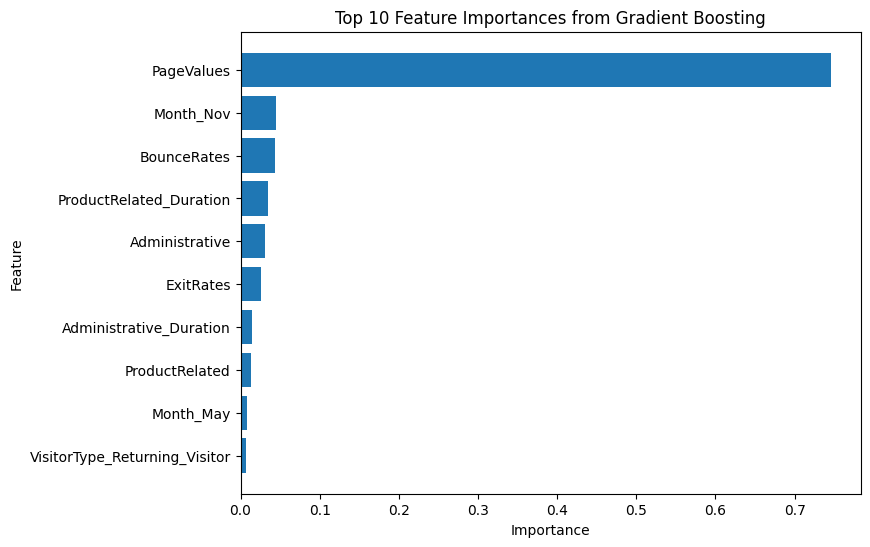

In [28]:
top_features = feature_importance.sort_values(by="importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.title("Top 10 Feature Importances from Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

`PageValues` dominates again, but the next features add useful context. `Month_Nov`, `BounceRates`, `ProductRelated_Duration`, `Administrative` and `ExitRates` all appear in the top group. The presence of `Month_Nov` and `Month_May` suggests that the original `Month` field may carry more signal than the mutual-information chart showed, because its effect is divided across individual month columns. This is checked later with permutation importance on the final contenders.

### Diagnostic: how much does the model lean on `PageValues`?

This is a first single-model check of the `PageValues` design issue. One untuned `Gradient Boosting` model is cross-validated on the training data, once with `PageValues` and once without it, to see how far performance moves.

In [29]:
X_train_with_pagevalues = X_train_original.copy()
X_train_without_pagevalues = X_train_original.drop(columns=["PageValues"])

numerical_features_without_pagevalues = [
    col for col in numerical_features_original
    if col != "PageValues"
]

preprocessor_with_pagevalues = build_preprocessor(numerical_features_original, categorical_features)
preprocessor_without_pagevalues = build_preprocessor(numerical_features_without_pagevalues, categorical_features)

# Same model used in both experiments
gb_with_pagevalues_pipeline = build_model_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_with_pagevalues
)
gb_without_pagevalues_pipeline = build_model_pipeline(
    GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_without_pagevalues
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_with_pagevalues = cross_validate(
    gb_with_pagevalues_pipeline,
    X_train_with_pagevalues,
    y_train_original,
    cv=CV_STRATEGY,
    scoring=scoring,
    n_jobs=-1
)

cv_without_pagevalues = cross_validate(
    gb_without_pagevalues_pipeline,
    X_train_without_pagevalues,
    y_train_original,
    cv=CV_STRATEGY,
    scoring=scoring,
    n_jobs=-1
)

pagevalues_cv_comparison = pd.DataFrame({
    "With PageValues": [
        cv_with_pagevalues["test_accuracy"].mean(),
        cv_with_pagevalues["test_precision"].mean(),
        cv_with_pagevalues["test_recall"].mean(),
        cv_with_pagevalues["test_f1"].mean()
    ],
    "Without PageValues": [
        cv_without_pagevalues["test_accuracy"].mean(),
        cv_without_pagevalues["test_precision"].mean(),
        cv_without_pagevalues["test_recall"].mean(),
        cv_without_pagevalues["test_f1"].mean()
    ]
}, index=["accuracy", "precision", "recall", "f1"])

pagevalues_cv_comparison["Difference"] = (
    pagevalues_cv_comparison["Without PageValues"]
    - pagevalues_cv_comparison["With PageValues"]
)

pagevalues_cv_comparison

,With PageValues,Without PageValues,Difference
accuracy,0.902295,0.845862,-0.056432
precision,0.728542,0.550415,-0.178126
recall,0.598290,0.079310,-0.518980
f1,0.656746,0.138221,-0.518525


Removing `PageValues` changes the model sharply. F1 falls from `0.657` to `0.138`, and recall falls from `0.598` to `0.079`, while accuracy only drops by `0.056`. This shows why accuracy is not enough for this task: the model can still classify most non-purchase sessions correctly, but almost stop finding buyers.

For now, `PageValues` remains part of the post-session design because the session has already finished, so page-value information can be used in the review. The important diagnostic point is how strongly the model relies on it. Section `4.7` repeats this comparison as a controlled design check across the three finalist model families on the held-out test split, where the with/without `PageValues` choice is looked at as Design A versus Design B.

## 3.3 Original-feature tuning

The strongest baseline candidates are tuned with `RandomizedSearchCV`, five-fold cross-validation and `scoring="f1"`, because F1 balances how many buyers are found with how many purchase predictions are correct. Random search is used instead of grid search because it allows a wider range of parameter values to be tested within the same compute budget.

Each model uses the same five-fold stratified, shuffled cross-validation and the same seed, defined once in `CV_STRATEGY`. Each search samples up to a set number of configurations, and any grid smaller than that is searched in full, so smaller models are not under-tuned relative to larger ones.

Class imbalance is handled during tuning by testing `class_weight="balanced"` where the model supports it, alongside the other hyperparameters.

### Tuning Gradient Boosting

In [30]:
gb_pipeline = build_model_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_original)

gb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}

gb_search = build_random_search(gb_pipeline, gb_param_grid, n_iter=6)
gb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(gb_search.best_params_)

print("Best cross-validation F1-score:")
print(gb_search.best_score_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best cross-validation F1-score:
0.654293105610568


In [31]:
# Initialise the tuned results list once
tuned_results = []

gb_tuned_results, gb_tuned_pred, gb_tuned_confusion = evaluate_model(
    "Tuned Gradient Boosting", gb_search, X_test_original, y_test_original
)
tuned_results.append(gb_tuned_results)
gb_tuned_results


Tuned Gradient Boosting
Confusion matrix:
[[1961   98]
 [ 136  246]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.95      0.94      2059
        True       0.72      0.64      0.68       382

    accuracy                           0.90      2441
   macro avg       0.83      0.80      0.81      2441
weighted avg       0.90      0.90      0.90      2441



{'model': 'Tuned Gradient Boosting',
 'accuracy': 0.9041376485047112,
 'precision': 0.7151162790697675,
 'recall': 0.643979057591623,
 'f1': 0.6776859504132231}

`Tuned Gradient Boosting` improves slightly over baseline, moving from F1 `0.668` to `0.678`. The selected model uses `100` boosting stages, `max_depth=3`, `min_samples_leaf=2` and `learning_rate=0.1`.

It is ruled in as a strong contender, with purchase-class precision `0.72` and recall `0.64`.

In [68]:
joblib.dump(gb_search, MODEL_DIR / "gb_original_search.joblib")

['../outputs/models/gb_original_search.joblib']

### Tuning Hist Gradient Boosting

In [32]:
hgb_pipeline = build_model_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_original)

hgb_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.1]
}

hgb_search = build_random_search(hgb_pipeline, hgb_param_grid, n_iter=6)
hgb_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(hgb_search.best_params_)

print("Best cross-validation F1-score:")
print(hgb_search.best_score_)

hgb_tuned_results, hgb_tuned_pred, hgb_tuned_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting", hgb_search, X_test_original, y_test_original
)
tuned_results.append(hgb_tuned_results)

Best parameters:
{'model__max_leaf_nodes': 15, 'model__max_iter': 200, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.1}
Best cross-validation F1-score:
0.6643238785188639

Tuned Hist Gradient Boosting
Confusion matrix:
[[1963   96]
 [ 143  239]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Hist Gradient Boosting` drops slightly against baseline, moving from F1 `0.674` to `0.667`. The selected model uses `max_leaf_nodes=15`, `max_iter=200`, `learning_rate=0.1` and `l2_regularization=0.1`.

It is ruled out as the lead boosting model, but kept in the comparison table.

### Tuning Support Vector Machine

In [33]:
svm_pipeline = build_model_pipeline(SVC(random_state=RANDOM_STATE), preprocessor_original)

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 50],
        "model__class_weight": ["balanced", None]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 50],
        "model__gamma": ["scale", 0.01, 0.1, 1],
        "model__class_weight": ["balanced", None]
    }
]

svm_search = build_random_search(svm_pipeline, svm_param_grid, n_iter=12)
svm_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(svm_search.best_params_)
print("\nBest CV F1-score:")
print(svm_search.best_score_)

svm_tuned_results, svm_tuned_pred, svm_tuned_confusion = evaluate_model(
    "Tuned Support Vector Machine", svm_search, X_test_original, y_test_original
)
tuned_results.append(svm_tuned_results)

Best parameters:
{'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__class_weight': 'balanced', 'model__C': 10}

Best CV F1-score:
0.6550471941876432

Tuned Support Vector Machine
Confusion matrix:
[[1833  226]
 [  86  296]]

Classification report:
              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441



`Tuned Support Vector Machine` improves over baseline, moving from F1 `0.608` to `0.655`. The selected model uses `kernel='rbf'`, `C=10`, `gamma=0.01` and `class_weight='balanced'`.

It is ruled out as the main model because, although recall is strong at `0.77`, precision stays lower at `0.57`.

### Tuning Logistic Regression

`Logistic Regression` is used as the interpretable linear comparator. Here, `C` and `l1_ratio` are tuned together so the model can test stronger or weaker regularisation and move between L2, L1 and elastic-net behaviour.

In [ ]:
# scikit-learn 1.8+ uses l1_ratio instead of the deprecated penalty argument [2].
# l1_ratio controls the regularisation mix: 0 = L2, 1 = L1, between 0 and 1 = Elastic Net.
# solver='saga' is used because it supports this full regularisation range.
logreg_pipeline = build_model_pipeline(
    LogisticRegression(
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    preprocessor_original
)

logreg_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.0, 0.5, 1.0]
}

logreg_search = build_random_search(logreg_pipeline, logreg_param_grid, n_iter=8)
logreg_search.fit(X_train_original, y_train_original)

print("Best parameters:", logreg_search.best_params_)
print("Best CV F1-score:", logreg_search.best_score_)

logreg_tuned_results, logreg_tuned_pred, logreg_tuned_confusion = evaluate_model(
    "Tuned Logistic Regression", logreg_search, X_test_original, y_test_original
)
tuned_results.append(logreg_tuned_results)

Best parameters: {'model__l1_ratio': 1.0, 'model__C': 0.01}
Best CV F1-score: 0.6495853300044673

Tuned Logistic Regression
Confusion matrix:
[[1853  206]
 [  94  288]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.90      0.93      2059
        True       0.58      0.75      0.66       382

    accuracy                           0.88      2441
   macro avg       0.77      0.83      0.79      2441
weighted avg       0.89      0.88      0.88      2441



`Tuned Logistic Regression` improves clearly over baseline, moving from F1 `0.534` to `0.658`. The selected model uses `C=0.01` and `l1_ratio=1.0`.

It is ruled in as the interpretable linear comparator, with recall `0.75` and directly readable coefficients, even though the ensembles remain stronger overall.

This notebook uses the scikit-learn 1.8+ API, where l1_ratio=0 gives L2 regularisation, l1_ratio=1 gives L1 regularisation, and values between them give elastic-net behaviour. The solver saga is used because it supports the full l1_ratio range, and the scaled preprocessing pipeline helps this solver converge properly. C and l1_ratio are tuned together so the model can test both the strength and type of regularisation.

In [69]:
joblib.dump(logreg_search, MODEL_DIR / "lr_original_search.joblib")

['../outputs/models/lr_original_search.joblib']

In [35]:
best_l1 = logreg_search.best_params_["model__l1_ratio"]
logreg_coef = logreg_search.best_estimator_.named_steps["model"].coef_.ravel()
zeroed = int((logreg_coef == 0).sum())
print(f"Selected l1_ratio: {best_l1} ({zeroed} of {logreg_coef.size} coefficients driven to zero)")

Selected l1_ratio: 1.0 (65 of 74 coefficients driven to zero)


The search selected `l1_ratio=1.0`, so this version of Logistic Regression model used `L1` regularisation under the scikit-learn 1.8+ API. This reduced the model to a small set of active predictors by setting `65 of the 74 coefficients` to zero, making the model useful as a readable benchmark. The coefficient interpretation in `4.6` thereofre focuses on the smaller set of features still active in the linear model.

### Tuning Random Forest

In [36]:
rf_pipeline = build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), preprocessor_original)

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}
rf_search = build_random_search(rf_pipeline, rf_param_grid, n_iter=30)
rf_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(rf_search.best_params_)
print("\nBest CV F1-score:")
print(rf_search.best_score_)

rf_tuned_results, rf_tuned_pred, rf_tuned_confusion = evaluate_model(
    "Tuned Random Forest",
    rf_search,
    X_test_original,
    y_test_original
)

tuned_results.append(rf_tuned_results)

Best parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best CV F1-score:
0.6805307891788474

Tuned Random Forest
Confusion matrix:
[[1927  132]
 [ 116  266]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.70      0.68       382

    accuracy                           0.90      2441
   macro avg       0.81      0.82      0.81      2441
weighted avg       0.90      0.90      0.90      2441



`Tuned Random Forest` improves over baseline, moving from F1 `0.643` to `0.682`. The selected model uses `300` trees, `max_depth=20`, `min_samples_leaf=2`, `min_samples_split=5`, `max_features='sqrt'` and `class_weight='balanced'`.

It is ruled in as the recall-leaning ensemble contender, finding `266` buyers with recall `0.70`.

In [70]:
joblib.dump(rf_search, MODEL_DIR / "rf_original_search.joblib")

['../outputs/models/rf_original_search.joblib']

### Tuning MLPClassifier

In [37]:
mlp_pipeline = build_model_pipeline(
    MLPClassifier(
        max_iter=1000,
        early_stopping=True,
        random_state=RANDOM_STATE
    ),
    preprocessor_original
)

mlp_param_grid = {
    "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
    "model__alpha": [0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.001, 0.01],
    "model__activation": ["relu", "tanh"]
}

mlp_search = build_random_search(mlp_pipeline, mlp_param_grid, n_iter=10)
mlp_search.fit(X_train_original, y_train_original)

print("Best parameters:")
print(mlp_search.best_params_)
print("\nBest CV F1-score:")
print(mlp_search.best_score_)

mlp_tuned_results, mlp_tuned_pred, mlp_tuned_confusion = evaluate_model(
    "Tuned MLPClassifier", mlp_search, X_test_original, y_test_original
)
tuned_results.append(mlp_tuned_results)

Best parameters:
{'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (50, 25), 'model__alpha': 0.01, 'model__activation': 'tanh'}

Best CV F1-score:
0.6385924658852798

Tuned MLPClassifier
Confusion matrix:
[[1979   80]
 [ 170  212]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2059
        True       0.73      0.55      0.63       382

    accuracy                           0.90      2441
   macro avg       0.82      0.76      0.78      2441
weighted avg       0.89      0.90      0.89      2441



`Tuned MLPClassifier` improves slightly over baseline, moving from F1 `0.600` to `0.631`. The selected model uses hidden layers `(50, 25)`, `activation='tanh'`, `alpha=0.01` and `learning_rate_init=0.01`.

It is ruled out as a lead model because the tuned tree ensembles still give stronger F1 and recall on this tabular dataset.

### Comparing the original-feature tuned models

In [76]:
# drop_duplicates guards against a model being appended twice if a tuning cell is re-run.
tuned_results_df = pd.DataFrame(tuned_results).drop_duplicates(subset="model").reset_index(drop=True)
tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
4,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051
0,Tuned Gradient Boosting,0.904138,0.715116,0.643979,0.677686
1,Tuned Hist Gradient Boosting,0.902089,0.713433,0.625654,0.666667
3,Tuned Logistic Regression,0.877100,0.582996,0.753927,0.657534
2,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867
5,Tuned MLPClassifier,0.897583,0.726027,0.554974,0.629080


In [77]:
tuned_results_df.to_csv(CACHE_DIR / "tuned_results_df.csv", index=False)

Across the original-feature tuning, `Tuned Random Forest` leads on F1 at `0.682` and has the strongest tree-ensemble recall at `0.696`. `Tuned Gradient Boosting` is close behind at F1 `0.678`, with higher precision at `0.715`.

`Tuned Random Forest` and `Tuned Gradient Boosting` are taken forward as the two design poles: one better balanced for finding buyers among the strongest ensembles, the other more selective when flagging likely purchases.

## 3.4 Feature engineering cycle

The earlier analysis and mutual information results pointed to session depth and product focus, so four summary engineered features are tested to see whether reshaping existing behaviour improves the models or provides clearer interpretation.

Four engineered features are added:

`total_pages`: total number of administrative, informational and product-related pages viewed.

`total_duration`: total time spent across administrative, informational and product-related pages.

`product_page_ratio`: proportion of viewed pages that were product-related.

`product_duration_ratio`: proportion of recorded browsing time spent on product-related pages.

### Create engineered session features

In [39]:
df_engineered = df.copy()

page_count_columns = ["Administrative", "Informational", "ProductRelated"]
duration_columns = ["Administrative_Duration", "Informational_Duration", "ProductRelated_Duration"]

df_engineered["total_pages"] = df_engineered[page_count_columns].sum(axis=1)

df_engineered["total_duration"] = df_engineered[duration_columns].sum(axis=1)

df_engineered["product_page_ratio"] = np.where(
    df_engineered["total_pages"] > 0,
    df_engineered["ProductRelated"] / df_engineered["total_pages"],
    0
)

df_engineered["product_duration_ratio"] = np.where(
    df_engineered["total_duration"] > 0,
    df_engineered["ProductRelated_Duration"] / df_engineered["total_duration"],
    0
)

engineered_feature_names = [
    "total_pages",
    "total_duration",
    "product_page_ratio",
    "product_duration_ratio"
]

df_engineered[engineered_feature_names].describe()

,total_pages,total_duration,product_page_ratio,product_duration_ratio
count,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,1323.454242,0.904126,0.851437
std,46.627336,2043.871589,0.142281,0.255850
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,231.666667,0.857143,0.831101
50%,20.000000,690.958333,0.961538,0.968646
75%,42.000000,1643.958333,1.000000,1.000000
max,746.000000,69921.647230,1.000000,1.000000


`total_pages` and `total_duration` are heavily skewed, with maximum values of `746` pages and `69,922` seconds. The ratio features cluster near `1`, with medians of `0.962` and `0.969`, so most sessions are already product-focused.

The ratio features may add limited new signal, but they give a clear measure of session focus and are worth testing.

### Train-test split with engineered features

In [40]:
X_engineered = df_engineered.drop(columns=["Revenue"])
y_engineered = df_engineered["Revenue"]

numerical_features_engineered = [
    col for col in X_engineered.columns
    if col not in categorical_features
]

X_train_engineered, X_test_engineered, y_train_engineered, y_test_engineered = train_test_split(
    X_engineered,
    y_engineered,
    test_size=0.2,
    stratify=y_engineered,
    random_state=RANDOM_STATE
)

print("Training features:", X_train_engineered.shape)
print("Test features:", X_test_engineered.shape)

Training features: (9764, 21)
Test features: (2441, 21)


The same `80/20` stratified split is used, giving `9,764` training rows and `2,441` test rows. Holding the split constant keeps the two cycles directly comparable.

### Mutual information with engineered features


In [41]:
preprocessor_engineered = build_preprocessor(numerical_features_engineered, categorical_features)

mi_preprocessor = clone(preprocessor_engineered)
X_train_processed_eng = mi_preprocessor.fit_transform(X_train_engineered)
processed_feature_names_eng = mi_preprocessor.get_feature_names_out()

mi_scores_eng = mutual_info_classif(X_train_processed_eng, y_train_engineered, random_state=RANDOM_STATE)

mi_scores_engineered_display_df = (
    pd.DataFrame({
        "feature": clean_feature_names(processed_feature_names_eng),
        "mutual_information": mi_scores_eng
    })
    .sort_values(by="mutual_information", ascending=False)
    .reset_index(drop=True)
)

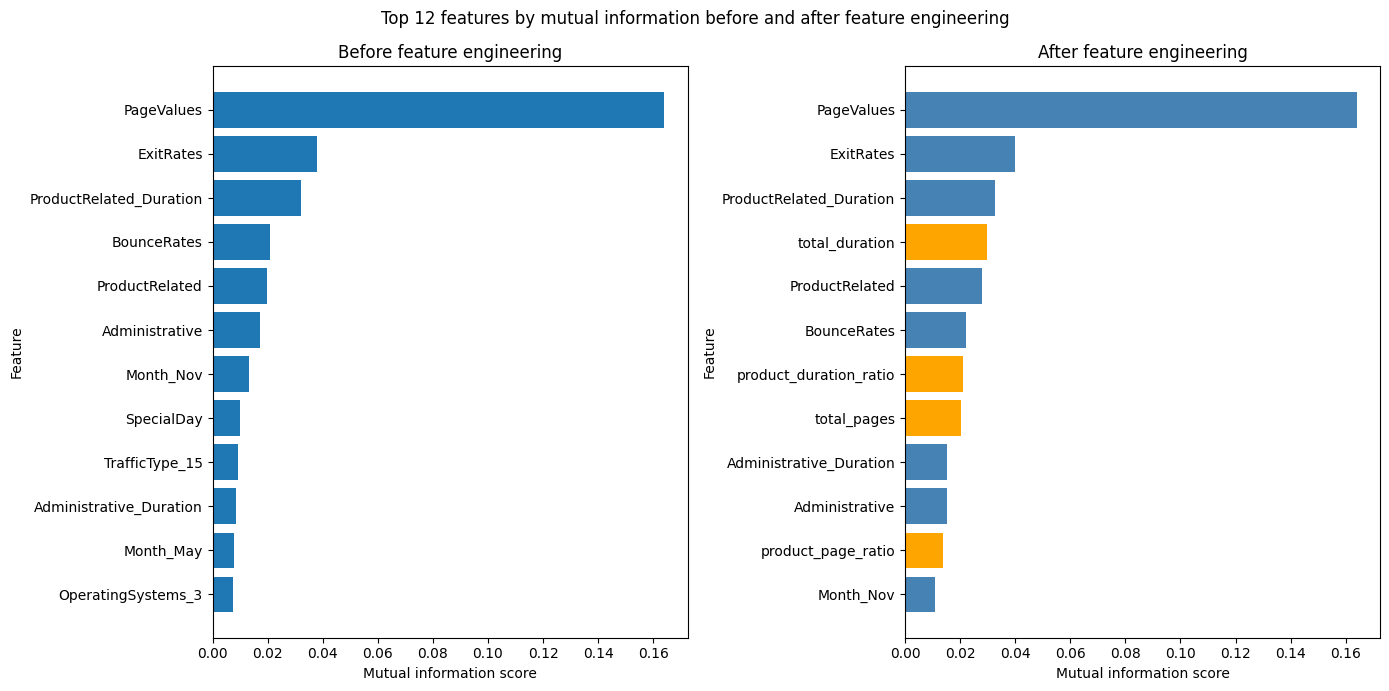

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True)

top_mi_original_features = (
    mi_scores_display_df
    .head(12)
    .sort_values("mutual_information")
)

top_mi_engineered_features = (
    mi_scores_engineered_display_df
    .head(12)
    .sort_values("mutual_information")
)

axes[0].barh(
    top_mi_original_features["feature"],
    top_mi_original_features["mutual_information"]
)
axes[0].set_title("Before feature engineering")
axes[0].set_xlabel("Mutual information score")
axes[0].set_ylabel("Feature")

engineered_colours = [
    "orange" if feature in engineered_feature_names else "steelblue"
    for feature in top_mi_engineered_features["feature"]
]

axes[1].barh(
    top_mi_engineered_features["feature"],
    top_mi_engineered_features["mutual_information"],
    color=engineered_colours
)
axes[1].set_title("After feature engineering")
axes[1].set_xlabel("Mutual information score")
axes[1].set_ylabel("Feature")

plt.suptitle("Top 12 features by mutual information before and after feature engineering")
plt.tight_layout()
plt.show()

`PageValues` remains the dominant individual feature after engineering. `ExitRates` and `ProductRelated_Duration` are still the strongest non-engineered behavioural signals.

All four engineered features enter the top twelve, led by `total_duration`. This suggests the added session-summary features carry some individual signal, but mutual information scores each feature on its own. The model-level value is tested next.

### Baseline modelling with engineered features

In [43]:
engineered_baseline_results = []
engineered_trained_pipelines = {}

for model_name, model in models.items():
    pipeline = build_model_pipeline(clone(model), preprocessor_engineered)

    pipeline.fit(X_train_engineered, y_train_engineered)

    results, y_pred, cm = evaluate_model(
        model_name,
        pipeline,
        X_test_engineered,
        y_test_engineered
    )

    engineered_baseline_results.append(results)
    engineered_trained_pipelines[model_name] = pipeline

engineered_baseline_results_df = pd.DataFrame(engineered_baseline_results)
engineered_baseline_results_df.sort_values(by="f1", ascending=False)


Logistic Regression
Confusion matrix:
[[2010   49]
 [ 225  157]]

Classification report:
              precision    recall  f1-score   support

       False       0.90      0.98      0.94      2059
        True       0.76      0.41      0.53       382

    accuracy                           0.89      2441
   macro avg       0.83      0.69      0.74      2441
weighted avg       0.88      0.89      0.87      2441


Decision Tree
Confusion matrix:
[[1880  179]
 [ 157  225]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.91      0.92      2059
        True       0.56      0.59      0.57       382

    accuracy                           0.86      2441
   macro avg       0.74      0.75      0.75      2441
weighted avg       0.87      0.86      0.86      2441


Random Forest
Confusion matrix:
[[1998   61]
 [ 183  199]]

Classification report:
              precision    recall  f1-score   support

       False       0.92      0.97

/Users/garyzolty/Desktop/University/AML/aml-online-shoppers/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,accuracy,precision,recall,f1
5,Gradient Boosting,0.901680,0.712575,0.623037,0.664804
6,Hist Gradient Boosting,0.898812,0.702703,0.612565,0.654545
2,Random Forest,0.900041,0.765385,0.520942,0.619938
4,Support Vector Machine,0.895535,0.745174,0.505236,0.602184
7,MLPClassifier,0.872184,0.598870,0.554974,0.576087
1,Decision Tree,0.862351,0.556931,0.589005,0.572519
0,Logistic Regression,0.887751,0.762136,0.410995,0.534014
3,K-Nearest Neighbours,0.868497,0.624490,0.400524,0.488038


The engineered baseline keeps the same pattern: `Gradient Boosting` leads at F1 `0.665`, followed by `Hist Gradient Boosting` at `0.655`. `Random Forest` remains more precision-leaning, with precision `0.765` but recall `0.521`. This screening selects which engineered models to tune rather than assuming the new features help.

### Tuning engineered-feature models

`Gradient Boosting`, `Hist Gradient Boosting` and `Random Forest` are the top three engineered baselines by F1. `Logistic Regression` is also tuned as the interpretable comparator, while the remaining lower-ranked models are not retuned in this cycle.

The engineered cycle reuses the original grids, search budgets and cross-validation, so the only variable between the cycles is the feature set. This keeps the comparison a clean feature-only experiment.


In [44]:
engineered_tuned_results = []
engineered_tuned_models = {}

### Gradient Boosting: strongest engineered contender

In [45]:
gb_engineered_pipeline = build_model_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
gb_engineered_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3],
    "model__min_samples_leaf": [1, 2]
}
gb_engineered_search = build_random_search(gb_engineered_pipeline, gb_engineered_param_grid, n_iter=6)
gb_engineered_search.fit(X_train_engineered, y_train_engineered)

gb_engineered_best_model = gb_engineered_search.best_estimator_

gb_engineered_results, gb_engineered_pred, gb_engineered_confusion = evaluate_model(
    "Tuned Gradient Boosting engineered",
    gb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)
engineered_tuned_results.append(gb_engineered_results)
engineered_tuned_models["Tuned Gradient Boosting engineered"] = gb_engineered_best_model
print(gb_engineered_search.best_params_, gb_engineered_search.best_score_)


Tuned Gradient Boosting engineered
Confusion matrix:
[[1960   99]
 [ 143  239]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.66       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 200, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1} 0.6549301193428195


`Tuned Gradient Boosting engineered` does not improve on the original-feature tuned version, moving from F1 `0.678` to `0.663`. The selected model uses `200` boosting stages, `max_depth=2`, `min_samples_leaf=2` and `learning_rate=0.1`.

It is ruled out as the lead engineered model for now, but kept in the comparison table because its precision remains solid at `0.71`.

### Hist Gradient Boosting: close engineered contender

In [46]:
hgb_engineered_pipeline = build_model_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
hgb_engineered_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31],
    "model__l2_regularization": [0, 0.001]
}
hgb_engineered_search = build_random_search(hgb_engineered_pipeline, hgb_engineered_param_grid, n_iter=6)
hgb_engineered_search.fit(X_train_engineered, y_train_engineered)

hgb_engineered_best_model = hgb_engineered_search.best_estimator_

hgb_engineered_results, hgb_engineered_pred, hgb_engineered_confusion = evaluate_model(
    "Tuned Hist Gradient Boosting engineered",
    hgb_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(hgb_engineered_results)
engineered_tuned_models["Tuned Hist Gradient Boosting engineered"] = hgb_engineered_best_model
print(hgb_engineered_search.best_params_, hgb_engineered_search.best_score_)


Tuned Hist Gradient Boosting engineered
Confusion matrix:
[[1961   98]
 [ 141  241]]

Classification report:
              precision    recall  f1-score   support

       False       0.93      0.95      0.94      2059
        True       0.71      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441

{'model__max_leaf_nodes': 15, 'model__max_iter': 100, 'model__learning_rate': 0.05, 'model__l2_regularization': 0} 0.6596500157755092


`Tuned Hist Gradient Boosting engineered` edges up slightly from the original-feature tuned version, moving from F1 `0.667` to `0.669`. The selected model uses `max_leaf_nodes=15`, `max_iter=100`, `learning_rate=0.05` and no L2 regularisation.

It is ruled in as the strongest engineered boosting model, but the gain is small, so it still needs to be judged against the full comparison table.

In [71]:
joblib.dump(hgb_engineered_best_model, MODEL_DIR / "hgb_engineered_model.joblib")

['../outputs/models/hgb_engineered_model.joblib']

### Random Forest: original benchmark retested with engineered features

In [47]:
rf_engineered_pipeline = build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE), preprocessor_engineered)
rf_engineered_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_features": ["sqrt", 0.5, 1.0],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__class_weight": ["balanced", None]
}
rf_engineered_search = build_random_search(rf_engineered_pipeline, rf_engineered_param_grid, n_iter=30)
rf_engineered_search.fit(X_train_engineered, y_train_engineered)

rf_engineered_best_model = rf_engineered_search.best_estimator_

rf_engineered_results, rf_engineered_pred, rf_engineered_confusion = evaluate_model(
    "Tuned Random Forest engineered",
    rf_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)

engineered_tuned_results.append(rf_engineered_results)
engineered_tuned_models["Tuned Random Forest engineered"] = rf_engineered_best_model
print(rf_engineered_search.best_params_, rf_engineered_search.best_score_)


Tuned Random Forest engineered
Confusion matrix:
[[1935  124]
 [ 130  252]]

Classification report:
              precision    recall  f1-score   support

       False       0.94      0.94      0.94      2059
        True       0.67      0.66      0.66       382

    accuracy                           0.90      2441
   macro avg       0.80      0.80      0.80      2441
weighted avg       0.90      0.90      0.90      2441

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 20, 'model__class_weight': 'balanced'} 0.6792744272960222


`Tuned Random Forest engineered` drops against the original-feature tuned version, moving from F1 `0.682` to `0.665`. The selected model uses the same structure as before: `300` trees, `max_depth=20`, `min_samples_leaf=2`, `min_samples_split=5`, `max_features='sqrt'` and `class_weight='balanced'`.

It is ruled out as an improvement over the original-feature Random Forest, although it still gives balanced purchase-class precision and recall at about `0.67` and `0.66`.

### Logistic Regression: interpretable engineered comparator

In [ ]:
# scikit-learn 1.8+ uses l1_ratio instead of the deprecated penalty argument [2]. 
# # l1_ratio controls the regularisation mix: 0 = L2, 1 = L1, between 0 and 1 = Elastic Net. 
# # solver='saga' is used because it supports this full regularisation range.
logreg_engineered_pipeline = build_model_pipeline(
    LogisticRegression(
        solver="saga",
        l1_ratio=0.0,
        C=1.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    preprocessor_engineered
)
logreg_engineered_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__l1_ratio": [0.0, 0.5, 1.0]
}

logreg_engineered_search = build_random_search(logreg_engineered_pipeline, logreg_engineered_param_grid, n_iter=8)
logreg_engineered_search.fit(X_train_engineered, y_train_engineered)

logreg_engineered_best_model = logreg_engineered_search.best_estimator_

logreg_engineered_results, logreg_engineered_pred, logreg_engineered_confusion = evaluate_model(
    "Tuned Logistic Regression engineered",
    logreg_engineered_best_model,
    X_test_engineered,
    y_test_engineered
)
engineered_tuned_results.append(logreg_engineered_results)
engineered_tuned_models["Tuned Logistic Regression engineered"] = logreg_engineered_best_model

print("Best parameters:", logreg_engineered_search.best_params_)
print("Best CV F1-score:", logreg_engineered_search.best_score_)


Tuned Logistic Regression engineered
Confusion matrix:
[[1839  220]
 [  89  293]]

Classification report:
              precision    recall  f1-score   support

       False       0.95      0.89      0.92      2059
        True       0.57      0.77      0.65       382

    accuracy                           0.87      2441
   macro avg       0.76      0.83      0.79      2441
weighted avg       0.89      0.87      0.88      2441

Best parameters: {'model__l1_ratio': 1.0, 'model__C': 0.01}
Best CV F1-score: 0.6441257373402108


`Tuned Logistic Regression engineered` is very close to the original-feature tuned version, moving from F1 `0.658` to `0.655`. The selected model again uses `C=0.01` and `l1_ratio=1.0`.

It is ruled out as a clear improvement from feature engineering, but kept as the interpretable engineered comparator because recall remains strong at `0.77`.

### Comparing engineered-feature contenders

In [49]:
engineered_tuned_results_df = (pd.DataFrame(engineered_tuned_results).drop_duplicates(subset="model", keep="last"))

engineered_tuned_results_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1
1,Tuned Hist Gradient Boosting engineered,0.902089,0.710914,0.630890,0.668516
2,Tuned Random Forest engineered,0.895944,0.670213,0.659686,0.664908
0,Tuned Gradient Boosting engineered,0.900860,0.707101,0.625654,0.663889
3,Tuned Logistic Regression engineered,0.873413,0.571150,0.767016,0.654749


In [80]:
engineered_tuned_results_df.to_csv(CACHE_DIR / "engineered_tuned_results_df.csv", index=False)

Within the engineered cycle, the tuned models are close, with F1-scores between `0.655` and `0.669`. `Tuned Hist Gradient Boosting engineered` is highest at F1 `0.669`, with precision `0.711` and recall `0.631`. `Tuned Logistic Regression engineered` is kept as the interpretable comparator, with the strongest recall at `0.767` but lower precision at `0.571`.

The engineered features contain useful summaries of session behaviour, but they do not materially improve the leading models. `Tuned Random Forest engineered` and `Tuned Gradient Boosting engineered` both sit below their original-feature tuned versions, while `Tuned Hist Gradient Boosting engineered` improves only slightly. The final comparison therefore carries forward the strongest original-feature models and the best engineered-feature contenders, rather than treating feature engineering as an automatic gain.

# Section 4: Evaluating Models and Analysing Results

## 4.1 Final comparison and shortlist

This cell reloads the saved tuned models and cached result tables so Section 4 can be rerun without repeating the expensive tuning cells.

For a full clean run, run the notebook from the top and allow all baseline, tuning and engineering cells to execute. For editing, run the imports, data loading, cleaning, feature preparation and train-test split cells first, then run this reload cell before continuing with Section 4.

The tuning cells only need to be rerun if the split, preprocessing, engineered features, parameter grids, random seed or model shortlist has changed.

In [81]:
rf_search = joblib.load(MODEL_DIR / "rf_original_search.joblib")
gb_search = joblib.load(MODEL_DIR / "gb_original_search.joblib")
hgb_engineered_best_model = joblib.load(MODEL_DIR / "hgb_engineered_model.joblib")
logreg_search = joblib.load(MODEL_DIR / "lr_original_search.joblib")

baseline_results_df = pd.read_csv(CACHE_DIR / "baseline_results_df.csv")
tuned_results_df = pd.read_csv(CACHE_DIR / "tuned_results_df.csv")
engineered_tuned_results_df = pd.read_csv(CACHE_DIR / "engineered_tuned_results_df.csv")

In [82]:
baseline_comparison_df = baseline_results_df.copy()
original_tuned_comparison_df = tuned_results_df.copy()
engineered_tuned_comparison_df = engineered_tuned_results_df.copy()

baseline_comparison_df["stage"] = "Baseline"
baseline_comparison_df["feature_set"] = "Original features"

original_tuned_comparison_df["stage"] = "Tuned"
original_tuned_comparison_df["feature_set"] = "Original features"

engineered_tuned_comparison_df["stage"] = "Tuned"
engineered_tuned_comparison_df["feature_set"] = "Engineered features"

final_comparison_df = pd.concat(
    [
        baseline_comparison_df,
        original_tuned_comparison_df,
        engineered_tuned_comparison_df
    ],
    ignore_index=True
)

final_comparison_df.sort_values(by="f1", ascending=False)

,model,accuracy,precision,recall,f1,stage,feature_set
12,Tuned Random Forest,0.898402,0.668342,0.696335,0.682051,Tuned,Original features
8,Tuned Gradient Boosting,0.904138,0.715116,0.643979,0.677686,Tuned,Original features
6,Hist Gradient Boosting,0.904957,0.727273,0.628272,0.674157,Baseline,Original features
15,Tuned Hist Gradient Boosting engineered,0.902089,0.710914,0.630890,0.668516,Tuned,Engineered features
5,Gradient Boosting,0.901680,0.708824,0.630890,0.667590,Baseline,Original features
9,Tuned Hist Gradient Boosting,0.902089,0.713433,0.625654,0.666667,Tuned,Original features
16,Tuned Random Forest engineered,0.895944,0.670213,0.659686,0.664908,Tuned,Engineered features
14,Tuned Gradient Boosting engineered,0.900860,0.707101,0.625654,0.663889,Tuned,Engineered features
11,Tuned Logistic Regression,0.877100,0.582996,0.753927,0.657534,Tuned,Original features
10,Tuned Support Vector Machine,0.872184,0.567050,0.774869,0.654867,Tuned,Original features


The full comparison shows that the strongest results come from the tuned original-feature models. `Tuned Random Forest` leads overall with F1 `0.682` and the strongest ensemble recall at `0.696`. `Tuned Gradient Boosting` is close behind with F1 `0.678` and higher precision at `0.715`.

The engineered models do not overtake the best original-feature models. `Tuned Hist Gradient Boosting engineered` is the strongest engineered option at F1 `0.669`, but the gain from feature engineering is not large enough to change the lead decision.

`Tuned Random Forest` and `Tuned Gradient Boosting` are ruled in as the main final contenders. `Tuned Hist Gradient Boosting engineered` is kept as the best engineered-feature comparison, and `Tuned Logistic Regression` is kept as the interpretable benchmark.

In [51]:
finalist_names = [
    "Tuned Random Forest",
    "Tuned Gradient Boosting",
    "Tuned Hist Gradient Boosting engineered",
    "Tuned Logistic Regression"
]

top_contenders = (
    final_comparison_df[final_comparison_df["model"].isin(finalist_names)]
    .copy()
    .sort_values(by="f1", ascending=False)
    .drop_duplicates(subset="model", keep="first")
    .reset_index(drop=True)
)

top_contenders[["model", "feature_set", "accuracy", "precision", "recall", "f1"]]

,model,feature_set,accuracy,precision,recall,f1
0,Tuned Random Forest,Original features,0.898402,0.668342,0.696335,0.682051
1,Tuned Gradient Boosting,Original features,0.904138,0.715116,0.643979,0.677686
2,Tuned Hist Gradient Boosting engineered,Engineered features,0.902089,0.710914,0.630890,0.668516
3,Tuned Logistic Regression,Original features,0.877100,0.582996,0.753927,0.657534


## 4.2 Ranking quality before a threshold is fixed

These curves judge how well each shortlisted model ranks sessions before any fixed cut-off is applied. Precision-recall is the more informative view because the purchase class is only `15.6%` of sessions.

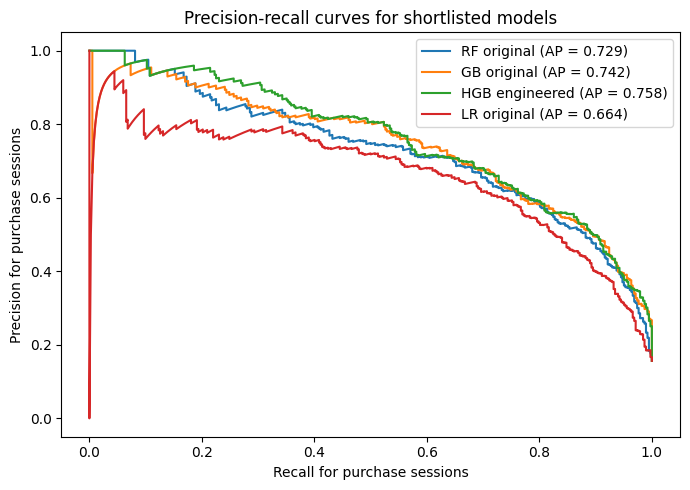

In [52]:
rf_test_proba = rf_search.best_estimator_.predict_proba(X_test_original)[:, 1] 
gb_test_proba = gb_search.best_estimator_.predict_proba(X_test_original)[:, 1] 
hgb_engineered_test_proba = hgb_engineered_best_model.predict_proba(X_test_engineered)[:, 1] 
lr_test_proba = logreg_search.best_estimator_.predict_proba(X_test_original)[:, 1]

curve_models = [ 
    ("RF original", y_test_original, rf_test_proba), 
    ("GB original", y_test_original, gb_test_proba), 
    ("HGB engineered", y_test_engineered, hgb_engineered_test_proba), 
    ("LR original", y_test_original, lr_test_proba) 
]

fig, ax = plt.subplots(figsize=(7, 5))

for name, y_true, proba in curve_models:
    precision, recall, _ = precision_recall_curve(y_true, proba)
    ax.plot(
        recall,
        precision,
        label=f"{name} (AP = {average_precision_score(y_true, proba):.3f})"
    )

ax.set_title("Precision-recall curves for shortlisted models")
ax.set_xlabel("Recall for purchase sessions")
ax.set_ylabel("Precision for purchase sessions")
ax.legend()

plt.tight_layout()
plt.show()

The precision-recall curve shows how cleanly each model finds buyers before choosing one final cut-off. A higher line means that, at the same recall level, the model is making more accurate purchase predictions.

`HGB engineered` is slightly strongest on this view. Its green curve sits above the other ensemble curves for much of the main part of the chart, and it has the highest average precision at `0.758`. `GB original` follows at `0.742`, then `RF original` at `0.729` and `LR original` at `0.664`.

This means `HGB engineered` is slightly better at putting real buyers near the top of its scored list. `LR original` is still useful as the readable benchmark, but it is not strong enough to be treated as a final deployment contender.

## 4.3 Operating point: confusion matrices at the default threshold

The precision-recall curve shows how the models rank sessions, whilst the confusion matrices show what happens at the default `0.50` cut-off. This makes the trade-off more concrete: how many buyers are found, how many are missed, and how many non-buyers are incorrectly flagged.

In [53]:

rf_original_pred = rf_search.predict(X_test_original)
gb_original_pred = gb_search.predict(X_test_original)
hgb_engineered_pred = hgb_engineered_best_model.predict(X_test_engineered)
lr_original_pred = logreg_search.predict(X_test_original)

rf_confusion_matrix = confusion_matrix(y_test_original, rf_original_pred)
gb_confusion_matrix = confusion_matrix(y_test_original, gb_original_pred)
hgb_engineered_confusion_matrix = confusion_matrix(y_test_engineered, hgb_engineered_pred)
lr_confusion_matrix = confusion_matrix(y_test_original, lr_original_pred)

def summarise_confusion_matrix(model_name, cm):
    tn, fp, fn, tp = cm.ravel()
    
    return {
        "model": model_name,
        "true_purchases_found": tp,
        "missed_purchases": fn,
        "false_purchase_predictions": fp,
        "correct_non_purchases": tn
    }

confusion_summary_df = pd.DataFrame([
    summarise_confusion_matrix("Tuned Random Forest", rf_confusion_matrix),
    summarise_confusion_matrix("Tuned Gradient Boosting", gb_confusion_matrix),
    summarise_confusion_matrix("Tuned Hist Gradient Boosting engineered", hgb_engineered_confusion_matrix),
    summarise_confusion_matrix("Tuned Logistic Regression", lr_confusion_matrix)
])

confusion_summary_df

,model,true_purchases_found,missed_purchases,false_purchase_predictions,correct_non_purchases
0,Tuned Random Forest,266,116,132,1927
1,Tuned Gradient Boosting,246,136,98,1961
2,Tuned Hist Gradient Boosting engineered,241,141,98,1961
3,Tuned Logistic Regression,288,94,206,1853


`LR original` finds the most purchase sessions at the default `0.50` cut-off, with `288` found and `94` missed. However, it also creates the most false purchase predictions at `206`, so the review list would be much less focused.

Among the ensemble contenders, `RF original` finds the most buyers, with `266` found and `116` missed, but it creates `132` false purchase predictions.

`GB original` and `HGB engineered` are more selective. Both create `98` false purchase predictions, but `GB original` finds slightly more buyers than `HGB engineered`, with `246` found compared with `241`.

This keeps `RF original` strongest when the priority is finding more buyers, while `GB original` is stronger when the priority is a tighter, more focused review list.

## 4.4 Threshold tuning using training data only

The default `0.50` cutoff gives the operating point above. `RF original` is better when the goal is to find more buyers, while `GB original` gives the tighter review list.

The next check tests whether `GB original` can be improved by moving the cutoff. To avoid choosing a threshold that simply fits the test set, the threshold is selected from out-of-fold predictions on the training data only, then applied once to the held-out test set.

In [54]:
from sklearn.model_selection import cross_val_predict

# Threshold choice is made on out-of-fold training predictions, then tested once
# on the held-out test set. This avoids choosing the threshold directly on test data.
gb_oof_proba = cross_val_predict(
    gb_search.best_estimator_,
    X_train_original,
    y_train_original,
    cv=CV_STRATEGY,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train_original, gb_oof_proba)

f1_by_threshold = (
    2 * precision[:-1] * recall[:-1]
) / (
    precision[:-1] + recall[:-1] + 1e-12
)

best_index = f1_by_threshold.argmax()
chosen_threshold = thresholds[best_index]

gb_test_proba = gb_search.best_estimator_.predict_proba(X_test_original)[:, 1]
gb_threshold_pred = (gb_test_proba >= chosen_threshold).astype(int)

print(
    f"Threshold {chosen_threshold:.2f} chosen on training data, applied to test "
    f"-> precision {precision_score(y_test_original, gb_threshold_pred):.3f}, "
    f"recall {recall_score(y_test_original, gb_threshold_pred):.3f}, "
    f"F1 {f1_score(y_test_original, gb_threshold_pred):.3f}"
)

Threshold 0.35 chosen on training data, applied to test -> precision 0.651, recall 0.723, F1 0.685


With the threshold chosen from out-of-fold training predictions, `GB original` uses a `0.35` cut-off on the test set. This raises F1 from `0.678` at the default `0.50` cut-off to `0.685`, with precision `0.651` and recall `0.723`.

This is useful as an alternative operating point if the audit wants to find more buyers, but the gain is small. For the final like-for-like comparison, the default `0.50` threshold is still used so the shortlisted models are compared on the same basis.

## 4.5 Stability check: repeated cross-validation

The held-out test split gives the clearest final comparison, but it is still only one split of the data. As a stability check, the main contenders are re-tested with repeated stratified cross-validation using `5` folds and `3` repeats.

Stratification keeps each fold close to the same buyer/non-buyer balance, which matters because buyers are the minority class. The train-CV F1 gap is also reported to check whether a model is gaining performance by overfitting the training folds rather than generalising.

This check adds another view of how stable each shortlisted model is before the final recommendation is made.

In [55]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

stability_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

stability_models = {
    "RF original": rf_search.best_estimator_,
    "GB original": gb_search.best_estimator_,
    "HGB engineered": hgb_engineered_best_model,
    "LR original": logreg_search.best_estimator_
}

stability_data = {
    "RF original": (X_train_original, y_train_original),
    "GB original": (X_train_original, y_train_original),
    "HGB engineered": (X_train_engineered, y_train_engineered),
    "LR original": (X_train_original, y_train_original)
}

stability_results = []

for model_name, model in stability_models.items():
    X_cv, y_cv = stability_data[model_name]
    
    cv_scores = cross_validate(
        model,
        X_cv,
        y_cv,
        cv=stability_cv,
        scoring="f1",
        return_train_score=True,
        n_jobs=-1
    )
    
    stability_results.append({
        "model": model_name,
        "train_f1_mean": cv_scores["train_score"].mean(),
        "train_f1_std": cv_scores["train_score"].std(),
        "cv_f1_mean": cv_scores["test_score"].mean(),
        "cv_f1_std": cv_scores["test_score"].std(),
        "train_cv_gap": cv_scores["train_score"].mean() - cv_scores["test_score"].mean()
    })

stability_results_df = (
    pd.DataFrame(stability_results)
    .sort_values(by="cv_f1_mean", ascending=False)
    .reset_index(drop=True)
)

stability_results_df

,model,train_f1_mean,train_f1_std,cv_f1_mean,cv_f1_std,train_cv_gap
0,RF original,0.919082,0.003473,0.679459,0.012337,0.239623
1,HGB engineered,0.735468,0.004352,0.662487,0.012014,0.072981
2,GB original,0.727887,0.005555,0.656824,0.016829,0.071064
3,LR original,0.652184,0.004216,0.650053,0.018027,0.002131


The repeated cross-validation results tell a similar story to the held-out test, but add an important warning. `RF original` still has the highest mean CV F1 at `0.679`, which matches its position as the strongest model on the single test split. However, its training F1 is much higher at `0.919`, giving a train-CV gap of `0.240`. Random Forest is fitting the training folds very strongly, so its lead should be treated with caution.

`HGB engineered` and `GB original` have slightly lower mean CV F1 scores at `0.662` and `0.657`, but their train-CV gaps are much smaller at `0.073` and `0.071`. This makes them more controlled alternatives, even though they do not quite match the Random Forest on average F1.

`LR original` is the most stable model, with a train-CV gap of only `0.002`, but its lower F1 keeps it as the readable benchmark rather than the lead model. Overall, `RF original` remains the strongest F1 model, while `HGB engineered` and `GB original` remain serious alternatives because their performance looks less dependent on fitting the training folds.

## 4.6 Interpretation: permutation importance and the readable benchmark

Two interpretation views are used. `LR original` is kept as the readable benchmark, so its standardised coefficients are inspected directly to show which feature groups carry the largest weight in the linear model.

Permutation importance then gives a post-training view for the main ensemble contenders: `GB original`, `RF original` and `HGB engineered`. This measures how much F1 falls when each feature is shuffled on the held-out test set. Encoded categorical features are grouped back to their original fields, so each design feature is judged once rather than split across several one-hot columns.

In [56]:
def group_encoded_features(feature_name):
    categorical_prefixes = [
        "Month_",
        "VisitorType_",
        "Weekend_",
        "OperatingSystems_",
        "Browser_",
        "Region_",
        "TrafficType_"
    ]

    for prefix in categorical_prefixes:
        if feature_name.startswith(prefix):
            return prefix.replace("_", "")

    return feature_name

In [57]:
logreg_original = logreg_search.best_estimator_
logreg_preprocessor = logreg_original.named_steps["preprocessor"]
logreg_model = logreg_original.named_steps["model"]

logreg_feature_names = clean_feature_names(logreg_preprocessor.get_feature_names_out())

logreg_coefficients = pd.DataFrame({
    "feature": logreg_feature_names,
    "coefficient": logreg_model.coef_[0]
})

logreg_coefficients["magnitude"] = logreg_coefficients["coefficient"].abs()

logreg_coefficients["feature_group"] = (
    logreg_coefficients["feature"]
    .apply(group_encoded_features)
)

logreg_grouped_coefficients = (
    logreg_coefficients
    .groupby("feature_group", as_index=False)["magnitude"]
    .sum()
    .sort_values(by="magnitude", ascending=False)
    .reset_index(drop=True)
)

active_logreg_grouped_coefficients = (
    logreg_grouped_coefficients[logreg_grouped_coefficients["magnitude"] > 0]
    .reset_index(drop=True)
)

active_logreg_grouped_coefficients

,feature_group,magnitude
0,PageValues,1.888392
1,Month,0.833610
2,ExitRates,0.529725
3,ProductRelated_Duration,0.106659
4,ProductRelated,0.090618
5,Administrative,0.076560
6,SpecialDay,0.044634
7,Informational,0.030658


The readable benchmark points in the same direction as the wider analysis. `PageValues` is the strongest active feature group, with magnitude of `1.888`, followed by `Month` at `0.834` and `ExitRates` at `0.530`.

The remaining active signals are much smaller. `ProductRelated_Duration`, `ProductRelated`, `Administrative`, `SpecialDay` and `Informational` still contribute, but with much lower magnitudes. The linear benchmark relies mainly on post-session page value, seasonality and exit behaviour, with browsing-depth features adding secondary signal.

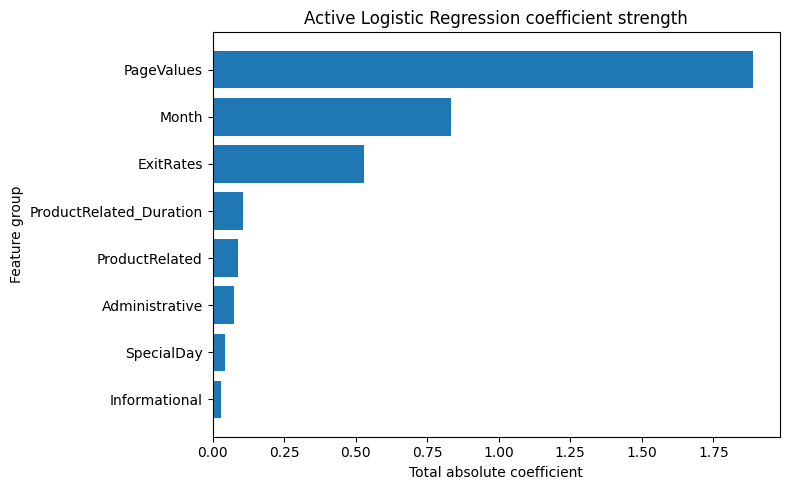

In [58]:
active_logreg_plot_df = (
    active_logreg_grouped_coefficients
    .sort_values(by="magnitude", ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    active_logreg_plot_df["feature_group"],
    active_logreg_plot_df["magnitude"]
)

plt.xlabel("Total absolute coefficient")
plt.ylabel("Feature group")
plt.title("Active Logistic Regression coefficient strength")

plt.tight_layout()
plt.show()

`LR original` is easiest to interpret because its predictions come from explicit feature coefficients. Since L1 regularisation sets most coefficients to zero, the model is reduced to a small set of active drivers that can be inspected directly. The one-hot encoded categories are grouped back to their original fields, so the chart shows the strength of each feature rather than each dummy variable. `PageValues` dominates, followed by `Month` and `ExitRates`.

Permutation importance is used here as a model-based interpretation check to see whether the other shortlisted models rely on the same signals.

In [59]:
permutation_models = {
    "GB original": (gb_search.best_estimator_, X_test_original, y_test_original),
    "RF original": (rf_search.best_estimator_, X_test_original, y_test_original),
    "HGB engineered": (hgb_engineered_best_model, X_test_engineered, y_test_engineered)
}

In [60]:
permutation_importance_tables = {}

for model_name, (fitted_model, X_test_data, y_test_data) in permutation_models.items():
    permutation_result = permutation_importance(
        fitted_model,
        X_test_data,
        y_test_data,
        scoring="f1",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    feature_importance_df = pd.DataFrame({
        "feature": X_test_data.columns,
        "importance_mean": permutation_result.importances_mean,
        "importance_std": permutation_result.importances_std
    })

    feature_importance_df["feature_group"] = (
        feature_importance_df["feature"]
        .apply(group_encoded_features)
    )

    grouped_importance_df = (
        feature_importance_df
        .groupby("feature_group", as_index=False)["importance_mean"]
        .sum()
        .sort_values(by="importance_mean", ascending=False)
        .reset_index(drop=True)
    )

    permutation_importance_tables[model_name] = grouped_importance_df

display(permutation_importance_tables["GB original"].head(8))
display(permutation_importance_tables["RF original"].head(8))
display(permutation_importance_tables["HGB engineered"].head(8))

,feature_group,importance_mean
0,PageValues,0.504976
1,Month,0.048326
2,ExitRates,0.025356
3,ProductRelated_Duration,0.014730
4,BounceRates,0.011938
5,Administrative,0.008769
6,ProductRelated,0.006811
7,TrafficType,0.002978


,feature_group,importance_mean
0,PageValues,0.472413
1,ExitRates,0.043457
2,Month,0.020181
3,ProductRelated,0.013553
4,ProductRelated_Duration,0.009030
5,TrafficType,0.007603
6,Weekend,0.004966
7,BounceRates,0.004545


,feature_group,importance_mean
0,PageValues,0.494431
1,ExitRates,0.046754
2,Month,0.042810
3,BounceRates,0.011535
4,TrafficType,0.004075
5,Informational,0.001849
6,Informational_Duration,0.001664
7,OperatingSystems,0.000832


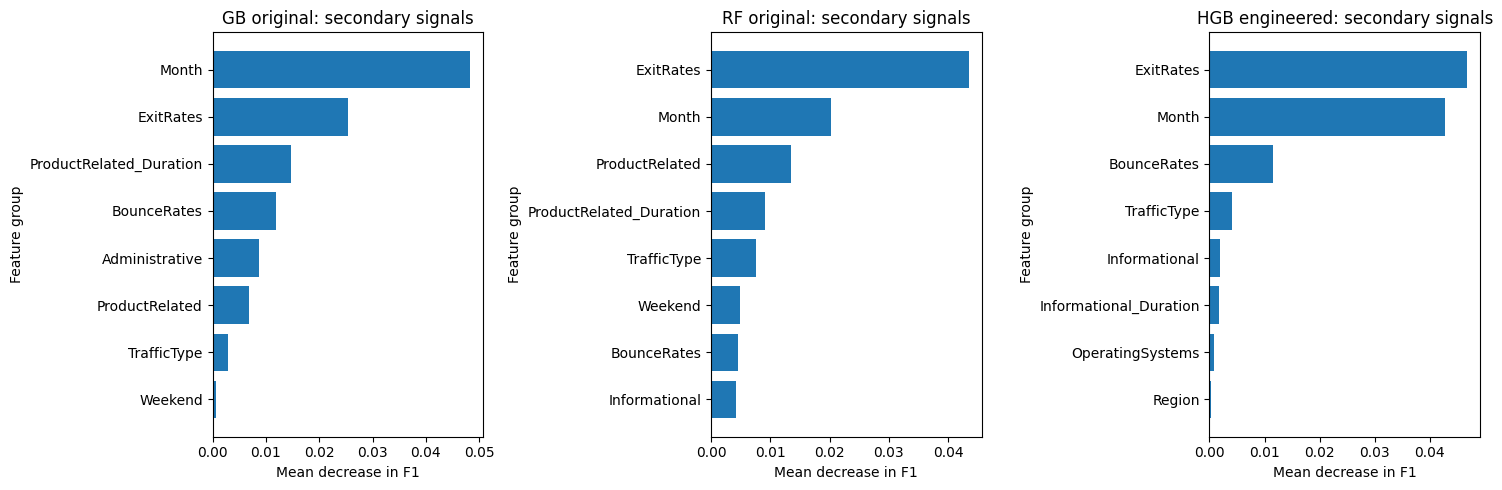

In [61]:
# Show secondary signals by hiding PageValues from the plot, not by refitting the model.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for axis, model_name in zip(axes, ["GB original", "RF original", "HGB engineered"]):
    secondary_importance_df = (
        permutation_importance_tables[model_name]
        .query("feature_group != 'PageValues'")
        .head(8)
        .sort_values(by="importance_mean")
    )

    axis.barh(
        secondary_importance_df["feature_group"],
        secondary_importance_df["importance_mean"]
    )

    axis.set_title(f"{model_name}: secondary signals")
    axis.set_xlabel("Mean decrease in F1")
    axis.set_ylabel("Feature group")

plt.tight_layout()
plt.show()

With `PageValues` is hidden from the chart, it is easier to see the secondary signals used by the models.

`GB original` relies most on `Month`, `ExitRates`, `ProductRelated_Duration` and `BounceRates`. `RF original` places more weight on `ExitRates`, `Month` and product-browsing activity, while `HGB engineered` relies on `ExitRates`, `Month` and `BounceRates`. 

`PageValues` drives much of the predictive strength, with behavioural and timing features adding supporting information.

## 4.7 PageValues sensitivity and final design boundary

`PageValues` is the dominant feature in this notebook. This is appropriate for the chosen task because the dataset is used as completed-session records, and the model is used as a post-session conversion audit not a live intervention model.

The earlier removal diagnostic showed that performance falls sharply without `PageValues`, with F1 dropping from `0.657` to `0.138` for the exploratory `Gradient Boosting` check. The permutation-importance results confirm the same pattern: shuffling `PageValues` causes the largest drop in F1, while `ExitRates`, `Month`, `BounceRates` and product-browsing features provide smaller secondary signals.

This defines the model's boundaries. The final model works well to audit completed sessions and study conversion drivers, however a real-time intervention model would need a separate design using only features available before checkout.

## 4.8 Final recommendation

The final choice is made from the shortlisted models using the held-out test results, confusion-matrix counts and repeated cross-validation stability check. F1 remains the main selection metric because buyers are the minority class, but the final decision also considers the kind of completed-session audit list each model would produce.

`Tuned Random Forest` using `original features` has the highest default-threshold F1 at `0.682` and the strongest ensemble recall at `0.696`, finding `266` purchase sessions. It is therefore retained as the recall-focused alternative, especially if the priority is to identify more possible buyers and accept a larger review workload.

`Tuned Gradient Boosting` using `original features` is selected as the primary completed-session audit model. Its F1 is only slightly lower at `0.678`, but it gives a cleaner review list, with precision `0.715` and only `98` false purchase predictions. Its smaller train-CV gap also makes it the more controlled recommendation for a focused audit workflow.

`Tuned Hist Gradient Boosting engineered` shows that the engineered-feature route was tested seriously, but it does not overtake the best original-feature models at the default classification threshold. `Tuned Logistic Regression` remains useful as the readable benchmark, because its coefficients help explain the main behavioural signals, but its lower precision keeps it out of the final deployment choice.

In [62]:
final_model_choice_df = top_contenders[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1"]
].copy()

# Confusion matrices were computed at the default 0.50 threshold in 4.3.
# The keys must match top_contenders["model"] exactly.
confusion_lookup = {
    "Tuned Random Forest": rf_confusion_matrix,
    "Tuned Gradient Boosting": gb_confusion_matrix,
    "Tuned Hist Gradient Boosting engineered": hgb_engineered_confusion_matrix,
    "Tuned Logistic Regression": lr_confusion_matrix
}

# Map finalist names to the names used in the 4.5 stability table.
stability_name_lookup = {
    "Tuned Random Forest": "RF original",
    "Tuned Gradient Boosting": "GB original",
    "Tuned Hist Gradient Boosting engineered": "HGB engineered",
    "Tuned Logistic Regression": "LR original"
}

def confusion_counts(model_name):
    tn, fp, fn, tp = confusion_lookup[model_name].ravel()
    
    return pd.Series({
        "buyers_found": tp,
        "missed_purchases": fn,
        "false_positives": fp,
        "correct_non_purchases": tn
    })

final_model_choice_df = pd.concat(
    [
        final_model_choice_df,
        final_model_choice_df["model"].apply(confusion_counts)
    ],
    axis=1
)

stability_lookup = stability_results_df.set_index("model")["train_cv_gap"]

final_model_choice_df["train_cv_gap"] = final_model_choice_df["model"].map(
    stability_name_lookup
).map(stability_lookup)

final_model_choice_df = (
    final_model_choice_df
    .sort_values(by="f1", ascending=False)
    .reset_index(drop=True)
)

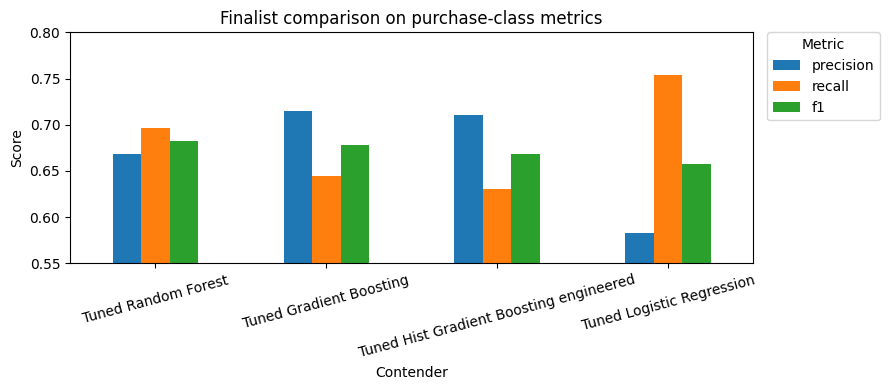

In [63]:

fig, ax = plt.subplots(figsize=(9, 4))

final_model_choice_df.set_index("model")[
    ["precision", "recall", "f1"]
].plot(
    kind="bar",
    ax=ax,
    rot=15
)

ax.set_ylim(0.55, 0.80)
ax.set_ylabel("Score")
ax.set_xlabel("Contender")
ax.set_title("Finalist comparison on purchase-class metrics")
ax.legend(title="Metric", loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()
plt.show()

In [64]:
display_columns = [
    "model",
    "feature_set",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "train_cv_gap",
    "buyers_found",
    "missed_purchases",
    "false_positives"
]

final_model_choice_df[display_columns].style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "train_cv_gap": "{:.3f}"
}).highlight_max(
    subset=["accuracy", "precision", "recall", "f1", "buyers_found"],
    color="lightblue"
).highlight_min(
    subset=["train_cv_gap", "missed_purchases", "false_positives"],
    color="lightgreen"
)

,model,feature_set,accuracy,precision,recall,f1,train_cv_gap,buyers_found,missed_purchases,false_positives
0,Tuned Random Forest,Original features,0.898,0.668,0.696,0.682,0.240,266,116,132
1,Tuned Gradient Boosting,Original features,0.904,0.715,0.644,0.678,0.071,246,136,98
2,Tuned Hist Gradient Boosting engineered,Engineered features,0.902,0.711,0.631,0.669,0.073,241,141,98
3,Tuned Logistic Regression,Original features,0.877,0.583,0.754,0.658,0.002,288,94,206


The table makes the final trade-off clear. `Tuned Random Forest` has the strongest F1 and recall, but `Tuned Gradient Boosting` produces a cleaner audit list, with fewer false positives and better stability.

For the completed-session audit design, the selected model is therefore not simply the highest-F1 option. It is the more controlled choice for producing useful purchase predictions for review.

## 4.9 Limitations and possible improvements

The project deliberately uses the dataset as completed-session records, matching its session-level structure. The final models are therefore post-session conversion-audit models, not live intervention tools.

`PageValues` fits this design, but it also defines the model boundary because it is highly influential and close to the revenue outcome. A live-prediction version would need a different feature set, fresh tuning and separate evaluation.

The random stratified split tests performance on unseen sessions from the same dataset, but not on a later trading period. Testing the model on data from a later time period would provide a more realistic assessment of how well it generalises over time.

`Tuned Random Forest` remains the recall-focused alternative, but its wider train-CV gap gives greater overfitting risk than `Tuned Gradient Boosting`. Engineered features added useful secondary signal, but did not replace `PageValues` as the dominant completed-session predictor.

## 4.10 Notebook summary

The dataset is used as a completed-session conversion audit because each row is already supplied as a session-level summary. The task is therefore to analyse finished browsing sessions and predict whether they produced revenue, rather than to build a live intervention system during an active visit.

Eight supervised classifiers were screened on the cleaned dataset. The strongest candidates were then tuned with `RandomizedSearchCV` using `scoring="f1"`, because buyers are the minority class and the model needs to balance finding purchase sessions with keeping purchase predictions useful. Original-feature and engineered-feature designs were compared on the same held-out stratified `80/20` split.

`PageValues` was the dominant predictor across the notebook. Mutual information, the removal diagnostic, the linear coefficient benchmark and permutation importance all showed the same pattern. This supports the completed-session audit framing, while the secondary signals from `ExitRates`, `Month`, `BounceRates`, product browsing and session timing show that the models are not relying on one field alone.

The final comparison gives two operational choices. `Tuned Gradient Boosting`, using original features, is selected as the main model because it gives a cleaner audit list with strong precision, competitive F1 and better stability. `Tuned Random Forest`, also using original features, is retained as the recall-focused alternative where finding more possible buyers is more important than limiting false positives. `Tuned Logistic Regression` remains the readable benchmark because it helps explain the main signals used by the stronger ensemble models.